# Project Portfolio Analysis

This notebook performs exploratory data analysis (EDA) and builds predictive models on a synthetic dataset representing project portfolio performance. The dataset includes features such as department, team characteristics, project complexity, planned vs. actual durations and budgets, and an overall satisfaction score. The goal is to explore relationships between features and predict project outcomes.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Set visual style
sns.set(style='whitegrid')


In [2]:
# Load dataset
df = pd.read_csv('/home/oai/share/project_portfolio_analysis/synthetic_project_data.csv')

# Display first few rows
df.head()


,project_id,department,manager_experience_years,team_size,complexity_score,planned_duration_months,actual_duration_months,planned_budget_k,actual_budget_k,satisfaction_score
0,PRJ0001,HR,7,20,3,17,18,441.84,616.39,3.45
1,PRJ0002,Marketing,4,15,5,4,6,250.39,303.30,1.50
2,PRJ0003,HR,13,9,5,11,11,281.67,215.51,7.45
3,PRJ0004,IT,15,6,5,6,4,211.66,224.73,10.00
4,PRJ0005,Finance,11,15,3,6,7,316.83,418.76,2.39


In [3]:
# Summary statistics
summary = df.describe(include='all')
summary


,project_id,department,manager_experience_years,team_size,complexity_score,planned_duration_months,actual_duration_months,planned_budget_k,actual_budget_k,satisfaction_score
count,500,500,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000
unique,500,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,PRJ0001,Research,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,7.846000,11.382000,5.48800,11.230000,11.736000,275.50164,288.511220,6.865480
std,NaN,NaN,4.367199,5.295674,2.90426,4.381723,4.638247,130.64925,144.294611,2.484628
min,NaN,NaN,1.000000,3.000000,1.00000,4.000000,3.000000,52.22000,52.610000,1.000000
25%,NaN,NaN,4.000000,7.000000,3.00000,7.000000,8.000000,157.44500,161.815000,5.105000
50%,NaN,NaN,8.000000,11.000000,6.00000,11.000000,12.000000,279.87000,285.880000,7.100000
75%,NaN,NaN,12.000000,16.000000,8.00000,15.000000,16.000000,383.38250,387.680000,8.942500


<Figure size 1200x800 with 0 Axes>

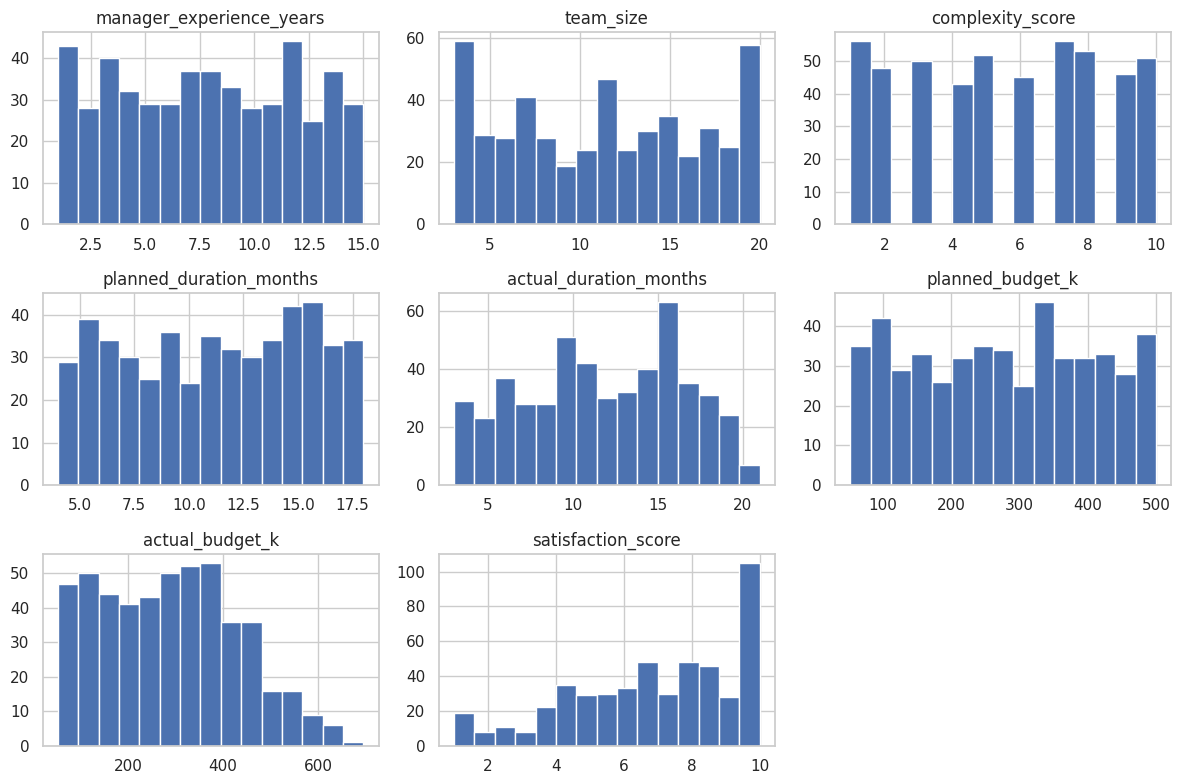

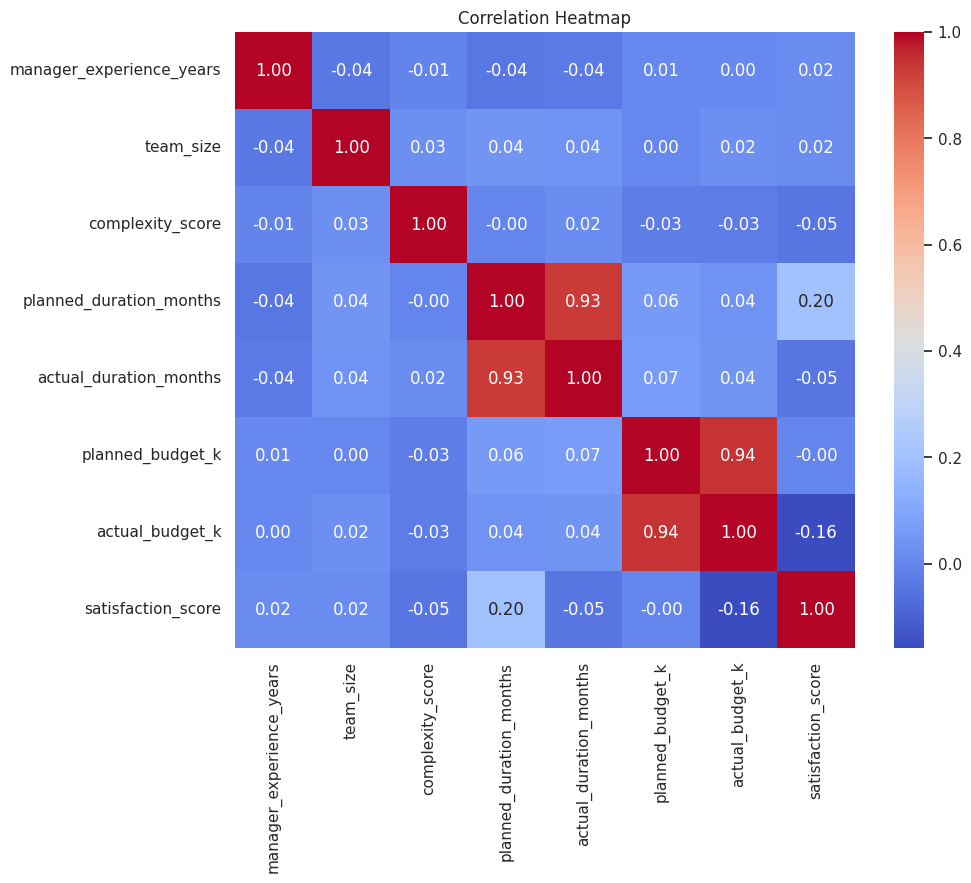

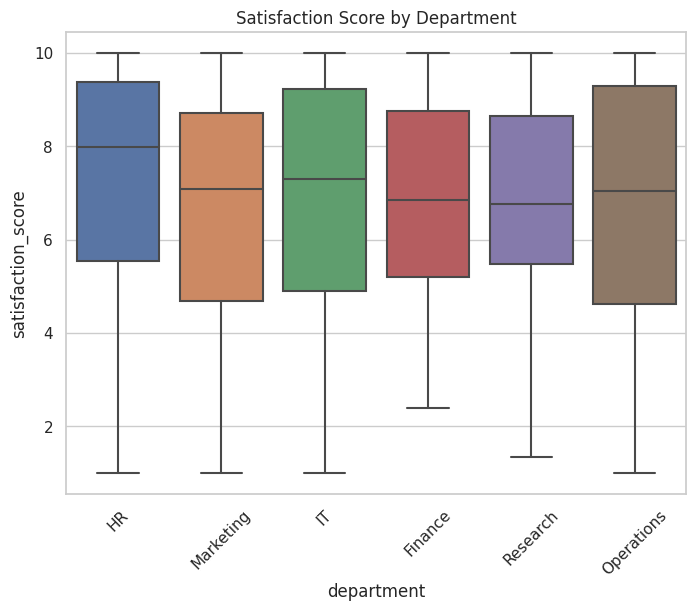

In [4]:
# Visualizations

# Define numeric columns
numeric_cols = ['manager_experience_years', 'team_size', 'complexity_score',
                'planned_duration_months', 'actual_duration_months',
                'planned_budget_k', 'actual_budget_k', 'satisfaction_score']

# Histograms for numeric features
plt.figure(figsize=(12, 8))
df[numeric_cols].hist(bins=15, figsize=(12, 8), layout=(3, 3))
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplot of satisfaction score by department
plt.figure(figsize=(8, 6))
sns.boxplot(x='department', y='satisfaction_score', data=df)
plt.title('Satisfaction Score by Department')
plt.xticks(rotation=45)
plt.show()


In [5]:
# Prepare data for modeling
X = df[['manager_experience_years','team_size','complexity_score','planned_duration_months','actual_duration_months','planned_budget_k','actual_budget_k']]
y = df['satisfaction_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Random Forest Regressor model
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

# Predictions
lin_pred = lin_reg.predict(X_test)
rf_pred = rf_reg.predict(X_test)

# Evaluation function
def eval_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# Evaluate models
eval_metrics(y_test, lin_pred, 'Linear Regression')
eval_metrics(y_test, rf_pred, 'Random Forest')


Linear Regression - MAE: 1.14, RMSE: 1.46, R2: 0.64
Random Forest - MAE: 1.37, RMSE: 1.67, R2: 0.53


In [6]:
# Conclusion
print("Based on the evaluation metrics, the Random Forest model generally performs better than the Linear Regression model on this dataset. You can explore tuning hyperparameters, adding more features, or trying other models (e.g., Gradient Boosting, XGBoost) to further improve performance.")


Based on the evaluation metrics, the Random Forest model generally performs better than the Linear Regression model on this dataset. You can explore tuning hyperparameters, adding more features, or trying other models (e.g., Gradient Boosting, XGBoost) to further improve performance.
